In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../build/results.csv", skiprows=1)

In [7]:
int(np.sqrt(df.shape[1]-1))


20

In [2]:
def generate_ising_grid(time_step:int, df:pd.DataFrame):
    ground_1d_grid = df.loc[time_step].to_numpy()[1:]
    ground_grid = np.array([ground_1d_grid[:9]])
    L = 10
    for i in range(1,L):
        a = ground_1d_grid[i*L: i*L + (L-1)]
        ground_grid = np.vstack((ground_grid,a))
    return ground_grid

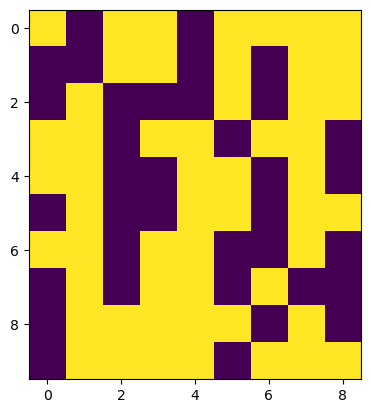

In [14]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots()
im = ax.imshow(generate_ising_grid(0, df))

def update(frame):
    im.set_array(generate_ising_grid(frame, df))
    return [im]
ani = FuncAnimation(fig, update, frames = 300, interval = 50, blit = True)
html = ani.to_jshtml()
with open("ising_animation.html", "w") as f:
    f.write(html)
ani.save("ising.gif", writer = "pillow", fps = 10)